In [1]:
import pandas as pd

df = pd.read_csv('../data/raw/HRDataset_v14.csv')
print(df.shape)

(311, 36)


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Employee_Name               311 non-null    object 
 1   EmpID                       311 non-null    int64  
 2   MarriedID                   311 non-null    int64  
 3   MaritalStatusID             311 non-null    int64  
 4   GenderID                    311 non-null    int64  
 5   EmpStatusID                 311 non-null    int64  
 6   DeptID                      311 non-null    int64  
 7   PerfScoreID                 311 non-null    int64  
 8   FromDiversityJobFairID      311 non-null    int64  
 9   Salary                      311 non-null    int64  
 10  Termd                       311 non-null    int64  
 11  PositionID                  311 non-null    int64  
 12  Position                    311 non-null    object 
 13  State                       311 non

In [3]:
df.isnull().sum()

Employee_Name                   0
EmpID                           0
MarriedID                       0
MaritalStatusID                 0
GenderID                        0
EmpStatusID                     0
DeptID                          0
PerfScoreID                     0
FromDiversityJobFairID          0
Salary                          0
Termd                           0
PositionID                      0
Position                        0
State                           0
Zip                             0
DOB                             0
Sex                             0
MaritalDesc                     0
CitizenDesc                     0
HispanicLatino                  0
RaceDesc                        0
DateofHire                      0
DateofTermination             207
TermReason                      0
EmploymentStatus                0
Department                      0
ManagerName                     0
ManagerID                       8
RecruitmentSource               0
PerformanceSco

In [4]:
df[df['ManagerID'].isnull()][['Employee_Name','Position','ManagerName']]

,Employee_Name,Position,ManagerName
19,"Becker, Scott",Production Technician I,Webster Butler
30,"Buccheri, Joseph",Production Technician II,Webster Butler
44,"Chang, Donovan E",Production Technician I,Webster Butler
88,"Fancett, Nicole",Production Technician II,Webster Butler
135,"Hutter, Rosalie",Production Technician II,Webster Butler
177,"Manchester, Robyn",Production Technician II,Webster Butler
232,"Rivera, Haley",Production Technician I,Webster Butler
251,"Sewkumar, Nori",Production Technician I,Webster Butler


In [5]:
df[df['ManagerName']=='Webster Butler'][['Employee_Name','ManagerID']].head(15)

,Employee_Name,ManagerID
4,"Anderson, Carol",39.0
19,"Becker, Scott",NaN
30,"Buccheri, Joseph",NaN
44,"Chang, Donovan E",NaN
65,"DeGweck, James",39.0
88,"Fancett, Nicole",NaN
89,"Ferguson, Susan",39.0
105,"Gilles, Alex",39.0
124,"Harrington, Christie",39.0
135,"Hutter, Rosalie",NaN


In [6]:
df['ManagerID'] = df['ManagerID'].fillna(39)

In [7]:
df.isnull().sum()['ManagerID']

np.int64(0)

In [8]:
df['TermReason'].value_counts()

TermReason
N/A-StillEmployed                   207
Another position                     20
unhappy                              14
more money                           11
career change                         9
hours                                 8
attendance                            7
return to school                      5
relocation out of area                5
no-call, no-show                      4
military                              4
retiring                              4
performance                           4
maternity leave - did not return      3
medical issues                        3
Learned that he is a gangster         1
Fatal attraction                      1
gross misconduct                      1
Name: count, dtype: int64

In [12]:
# Dates had mixed formats (e.g. 3/30/2015 and 07-05-2011), so using format='mixed's
df['DateofHire'] = pd.to_datetime(df['DateofHire'], format='mixed')
df['DateofTermination'] = pd.to_datetime(df['DateofTermination'], format='mixed')
df[['DateofHire','DateofTermination']].dtypes

DateofHire           datetime64[ns]
DateofTermination    datetime64[ns]
dtype: object

In [13]:
df[['Employee_Name','DateofHire','DateofTermination']].head()

,Employee_Name,DateofHire,DateofTermination
0,"Adinolfi, Wilson K",2011-07-05,NaT
1,"Ait Sidi, Karthikeyan",2015-03-30,2016-06-16
2,"Akinkuolie, Sarah",2011-07-05,2012-09-24
3,"Alagbe,Trina",2008-01-07,NaT
4,"Anderson, Carol",2011-07-11,2016-09-06


In [14]:
df.to_csv('../data/cleaned/HRDataset_cleaned.csv', index=False)

In [15]:
df['DateofTermination_filled'] = df['DateofTermination'].fillna(pd.Timestamp.today())
df['TenureDays'] = (df['DateofTermination_filled'] - df['DateofHire']).dt.days
df[['Employee_Name','DateofHire','DateofTermination','TenureDays']].head()

,Employee_Name,DateofHire,DateofTermination,TenureDays
0,"Adinolfi, Wilson K",2011-07-05,NaT,5539
1,"Ait Sidi, Karthikeyan",2015-03-30,2016-06-16,444
2,"Akinkuolie, Sarah",2011-07-05,2012-09-24,447
3,"Alagbe,Trina",2008-01-07,NaT,6814
4,"Anderson, Carol",2011-07-11,2016-09-06,1884


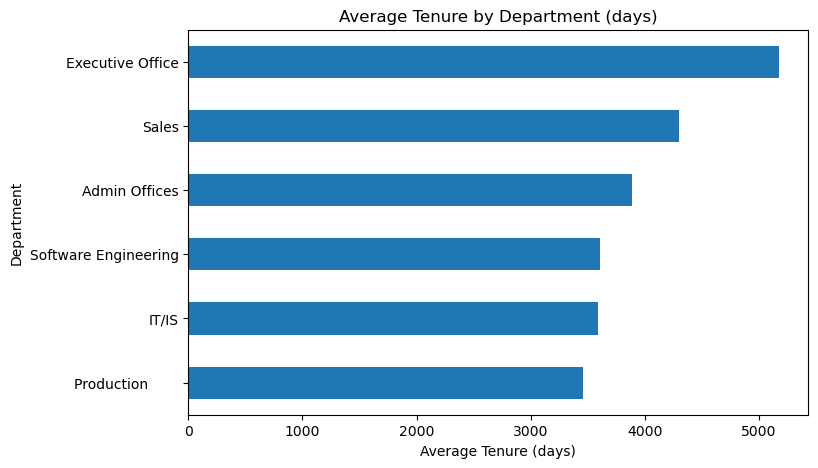

In [16]:
import matplotlib.pyplot as plt

avg_tenure = df.groupby('Department')['TenureDays'].mean().sort_values()
avg_tenure.plot(kind='barh', figsize=(8,5), title='Average Tenure by Department (days)')
plt.xlabel('Average Tenure (days)')
plt.show()

In [17]:
df.groupby('EmploymentStatus')['EngagementSurvey'].mean()

EmploymentStatus
Active                    4.119807
Terminated for Cause      3.596875
Voluntarily Terminated    4.180227
Name: EngagementSurvey, dtype: float64